# Coursework 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Linear regression and feature selection <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
  - [(1.3)](#task-13) <a name="index-task-13"></a>
  - [(1.4)](#task-14) <a name="index-task-14"></a>
- [Task 2](#task-2): Non-linear regression with Kernel Ridge Regression <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>
- [Task 3](#task-3): Classification with the Multi-Layer Perceptron <a name="index-task-3"></a>
  - [(3.1)](#task-31) <a name="index-task-31"></a>
  - [(3.2)](#task-32)  <a name="index-task-32"></a>



---



<a name="task-1"></a>

# Task 1: Linear regression and feature selection [(index)](#index-task-1)

In [1]:
# import useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# set global config for matplotlib to make plots readable
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

rng = np.random.default_rng(0)

In [2]:
# load data
data_train = pd.read_csv("asteroid_observations_train.csv")
data_test = pd.read_csv("asteroid_observations_test.csv")

# show the shape of the data
print("train data shape: ", data_train.shape)
print("test data shape: ", data_test.shape)

data_train.head()

train data shape:  (638, 9)
test data shape:  (160, 9)


,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,18.1,0.041,15,2.0,0.201590,11.975800,3.912298,1.573,MBA
1,12.5,0.139,349,7208.0,0.032746,8.793883,11.942668,12.355,TJN
2,14.1,0.062,705,25309.0,0.179314,27.433960,5.749452,8.862,OMB
3,16.9,0.097,91,3805.0,0.066114,13.813845,4.592982,2.139,MBA
4,11.5,0.062,1300,9606.0,0.008824,5.595907,12.006096,30.763,TJN


In [3]:
data_test.head()

,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,16.00,0.061,371,9126.0,0.144324,12.018294,4.266851,3.888,MBA
1,14.20,0.079,528,10262.0,0.049446,20.973974,5.802442,7.860,OMB
2,10.71,0.045,2464,35751.0,0.185255,5.629857,7.950795,45.117,OMB
3,13.00,0.054,1157,9248.0,0.134931,4.428840,7.884727,15.014,OMB
4,15.20,0.075,390,7176.0,0.071674,16.578118,5.460715,5.330,MBA


In [4]:
# features
features = data_test.columns[:-2]
features

Index(['Absolute magnitude', 'Albedo', 'Number of observations',
       'Observation arc length', 'Orbital eccentricity', 'Orbital inclination',
       'Orbital period'],
      dtype='str')

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

In [5]:
# create data matrix
X_train = np.asarray(data_train.iloc[:, :-2])
X_test = np.asarray(data_test.iloc[:, :-2])

# create label vector
y_train = np.asarray(data_train.loc[:, 'Asteroid diameter'])
y_test = np.asarray(data_test.loc[:, 'Asteroid diameter'])

In [6]:
# standardise data to expection = 0 and standard deviation = 1
def standardise(X, X_train_=None):
    """
    Standardise features.

    Parameters:
        X (np.array): Feature matrix.
        X_train_ (np.array): An optional feature matrix to compute the statistics
            from before applying it to X. If None, just use X to compute the statistics.

    Returns:
        X_std (np.array): Standardised feature matrix
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std

X_train_std = standardise(X=X_train)
X_test_std = standardise(X=X_test, X_train_=X_train)

The solution of the the (ordinary) least squares is
$$
\boldsymbol{\hat{\beta}^{LS}} = (\boldsymbol X^T\boldsymbol X)^{-1}\boldsymbol X^T\boldsymbol y \,,
$$

In the method fit_ols(), we add an interception feature on the first column of the data matrix $X$, so it returns
$$
\boldsymbol{\hat{\beta}^{LS}}  = (\hat{\beta}_{0}^{LS}, \hat{\beta}_{1}^{LS}, \dots, \hat{\beta}_{p}^{LS})^T
$$


In [7]:
# fit the ordinary least squares
def fit_ols(X, y):
    """
    solution of OLS problem.
    assume X without interception.

    Parameters:
        X (np.array): Feature matrix.
        y (np.array): label

    Returns:
        beta_ls (np.array): coefficient of ols
    """
    # check the shape
    N, p = X.shape
    y = np.asarray(y).reshape(-1, 1)
    assert y.shape[0] == N

    # add intercept
    X_aug = np.hstack([np.ones((N, 1)), X])

    # apply formula
    beta_ls = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    assert beta_ls.shape[0] == (p + 1)
    
    return beta_ls.flatten()

For Garrote, $f_{\boldsymbol{\beta}^G,\hat{\beta}_0^{LS}}(x) = x^{T}\boldsymbol{\beta}^G + \hat{\beta}_0^{LS}$ where $\beta^{G}_{j} = g_j\hat{\beta}^{LS}_{j}$

The optimisation problem is:
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}-f_{\beta^G,\hat{\beta}_0^{LS}}\!\left(x^{(i)}\right)\right)^2
\right].
\\
\text{such that }
\lVert_{} \boldsymbol{g}\rVert_{1}=\sum_{j=1}^{p}\lvert g_{j}\rvert < s
\qquad \text{for some } s\in\mathbb{R}_{\ge 0}.
$$
which is equivalent to
$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}\sum_{i=1}^{N^{\mathrm{train}}}
\left(y^{(i)}- {x^{(i)}}^{T} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS}\right)^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$


since we can rewrite $\boldsymbol{\beta}^{G} = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)g$, let $D = \text{diag}(\hat{\beta}^{LS}_1, \hat{\beta}^{LS}_2, \dots, \hat{\beta}^{LS}_p)$, so the optimisation problem is 

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} \boldsymbol{\beta}^G - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

$$
\min_{\boldsymbol{g}}\left[\frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \lVert_{} \boldsymbol{g}\rVert_{1}
\right].
$$

Replace $\lVert_{} \boldsymbol{g}\rVert_{1}$ by Huber loss $\sum_{i=1}^{p} L_c(g_i)$

$$
L_c (g_i) =
\begin{cases}
 \frac{1}{2}{g^2_i}                   & \text{for } |g_i| \le c, \\
 c (|g_i| - \frac{1}{2}c), & \text{otherwise,}
\end{cases}
$$

$$
\frac{dL_c (g_i)}{d g_i} =
  \begin{cases}
 g_i                   & \text{for } |g_i| \le c, \\
 c\, \text{sign}(g_i) , & \text{otherwise,}
\end{cases}
$$

So the final Loss function is

$$
L(\boldsymbol g) = \frac{1}{N^{\mathrm{train}}}
\|\boldsymbol y - {X} {D} \boldsymbol g - \hat{\beta}_0^{LS} \mathbf{1} \|_2^2 + \lambda \sum_{i=1}^{p} L_c(g_i). \\
= \frac{1}{N^{\mathrm{train}}}
(\boldsymbol{y}^T \boldsymbol{y} - \boldsymbol{g}^T (\boldsymbol{X}D)^T \boldsymbol{y} - \boldsymbol{y}^T (\boldsymbol{X}D) \boldsymbol{g}
+ \boldsymbol{g}^T(\boldsymbol{X}D)^T(\boldsymbol{X}D)\boldsymbol{g} \\
- \hat{\beta_0^{LS}} \mathbf{1}^T \boldsymbol y - \hat{\beta_0^{LS}} \boldsymbol{y}^T \mathbf{1} + \hat{\beta_0^{LS}}^2 \mathbf{1}^T\mathbf{1} \\
+ \hat{\beta_0^{LS}} (\mathbf{1}^T \boldsymbol X D) \boldsymbol{g} + \hat{\beta_0^{LS}} \boldsymbol{g}^T (\boldsymbol X D)^T \mathbf{1}) \\
+ \lambda \sum_{i=1}^{p} L_c(g_i)
$$

So the gradient of the loss funtion is
$$
\nabla_{\boldsymbol g}{L} = \frac{2}{N^{\mathrm{train}}} (\boldsymbol X D)^T (\boldsymbol X Dg + \hat{\beta}_0^{LS} \mathbf{1} - \boldsymbol y) + \lambda \nabla_{\boldsymbol g}{L_c}
$$

In [8]:
# huber loss
def huber(g, c_huber=1e-4):
    """
    huber loss

    Parameters:
        g (np.array): Feature matrix.
        c_huber (float): smooth parameter

    Returns:
        np.array: the huber loss
    """
    return np.where(np.abs(g) <= c_huber, (g ** 2) / 2., c_huber * (np.abs(g) - c_huber / 2))

# gradient of huber loss
def grad_huber(g, c_huber=1e-4):
    """
    gradient of huber loss

    Parameters:
        g (np.array): Feature matrix.
        c_huber (float): smooth parameter

    Returns:
        np.array: gradient of the huber loss
    """
    return  np.where(np.abs(g) <= c_huber, g, c_huber * np.sign(g))

In [9]:
# loss function
def compute_loss(g, X, y, beta, lambd, c_huber=1e-4):
    """
    compute the value of loss funtion

    Parameters:
        g: (p) vector: factor of garrote coeffient
        X: (N, p) matrix: data
        y: (N) vector: label
        beta: (p + 1) vector: the learnt parametre of OLS
        lambd (float): regulation parametre
        c_huber (float): smooth parameter

    Returns:
        loss (np.array): loss
    """
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    assert beta_1_p.shape[0] == p

    # X @ D
    XD = X * beta_1_p

    huber_loss = huber(g, c_huber)
    loss = (1 / N_train) * np.sum((y - XD @ g - beta_0) ** 2) + lambd * np.sum(huber_loss)

    return loss

# gradient of loss function
def grad_loss(g, X, y, beta, lambd, c_huber=1e-4):
    """
    compute the gradient of loss funtion

    Parameters:
        g: (p) vector: factor of garrote coeffient
        X: (N, p) matrix: data
        y: (N) vector: label
        beta: (p + 1) vector: the learnt parametre of OLS
        lambd (float): regulation parametre
        c_huber (float): smooth parameter

    Returns:
        grad (np.array): gradient of loss
    """
    N_train, p = X.shape
    assert y.shape[0] == N_train

    # extract the interception and D matrix and other useful vector
    beta_0 = beta[0]
    beta_1_p = beta[1:]
    assert beta_1_p.shape[0] == p

    # compute the gradient of Huber loss part
    grad_c = grad_huber(g, c_huber=c_huber)

    # compute the gradient of the loss funtion
    XD = X * beta_1_p
    grad = (2 / N_train) * XD.T @ (XD @ g + beta_0 - y) + lambd * grad_c

    return grad

Then we implement gradient descent since there is no analytic solution for this problem.
$$
\boldsymbol{g}_{t + 1} = \boldsymbol{g}_{t} - \eta_t \nabla_{\boldsymbol g} L(\boldsymbol{g}_{t})

In [10]:
def gradient_descent(X, y, beta, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    """
    Gradient descent to optimise the coeffcient.

    Parameters:
        X: (N, p) matrix: data
        y: (N) vector: label
        beta: (p + 1) vector: the learnt parameter of OLS
        lambd (float): regulation parametre
        n_iters (int): number of iterations
        step_size (float): step size of gradient descent
        c_huber (float): smooth parameter
        print_outcome (bool): if print the outcome

    Returns:
        g (np.array): (p,) vector result of the optimisation problem
        loss_history (list): record the loss
        epochs_list (list): record the epochs
    """
    N, p = X.shape
    assert y.shape[0] == N

    # initialize the parametre
    g = np.zeros(p)
    nth = 0
    loss_history = []  # Track loss values
    epochs_list = []  # Track epoch numbers

    for epoch in range(1, n_iters + 1):
        # update g
        grad = grad_loss(g, X, y, beta, lambd, c_huber)
        g = g - step_size * grad

        # Record loss 
        if epoch == 2**nth or epoch == n_iters:
            # Compute the current loss
            loss = compute_loss(g, X, y, beta, lambd, c_huber)
            if print_outcome:
                print(f'Epoch: {epoch}, Loss: {loss:.6f}')

            # Update tracking variables
            epochs_list.append(epoch)
            loss_history.append(loss)
            nth += 1

    return g, loss_history, epochs_list

The train process is :
1. fit OLS and get $\hat{\boldsymbol\beta}^{LS}$
2. gradient descent on Garrote problem and get $\boldsymbol g$
3. get $\hat{\boldsymbol\beta}^{G}$

In [11]:
def train_garrote(X_train, y_train, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4, print_outcome=False):
    """
    the training process

    Parameters:
        X_train: (N, p) matrix: training data
        y_train: (N) vector: label
        lambd (float): regulation parametre
        n_iters (int): number of iterations
        step_size (float): step size of gradient descent
        c_huber (float): smooth parameter
        print_outcome (bool): if print the outcome

    Returns:
        beta_G (np.array): coefficient of Garrote
        beta_LS (np.array): the learnt parameter of OLS
        g (np.array): (p,) vector result of the optimisation problem
        loss_history (list): record the loss
        epochs_list (list): record the epochs
    """
    # check dimention
    N, p = X_train.shape
    assert y_train.shape[0] == N

    # first get the ols coefficient
    beta_LS = fit_ols(X_train, y_train)

    # use gradient descent to get the optimal g
    g, loss_history, epochs_list = gradient_descent(X_train, y_train, beta_LS, lambd, n_iters, step_size, c_huber, print_outcome)

    # get the Garrote coefficient
    beta_G = g * beta_LS[1:]

    return beta_G, beta_LS, g, loss_history, epochs_list

train on the $S_{\lambda}$ set

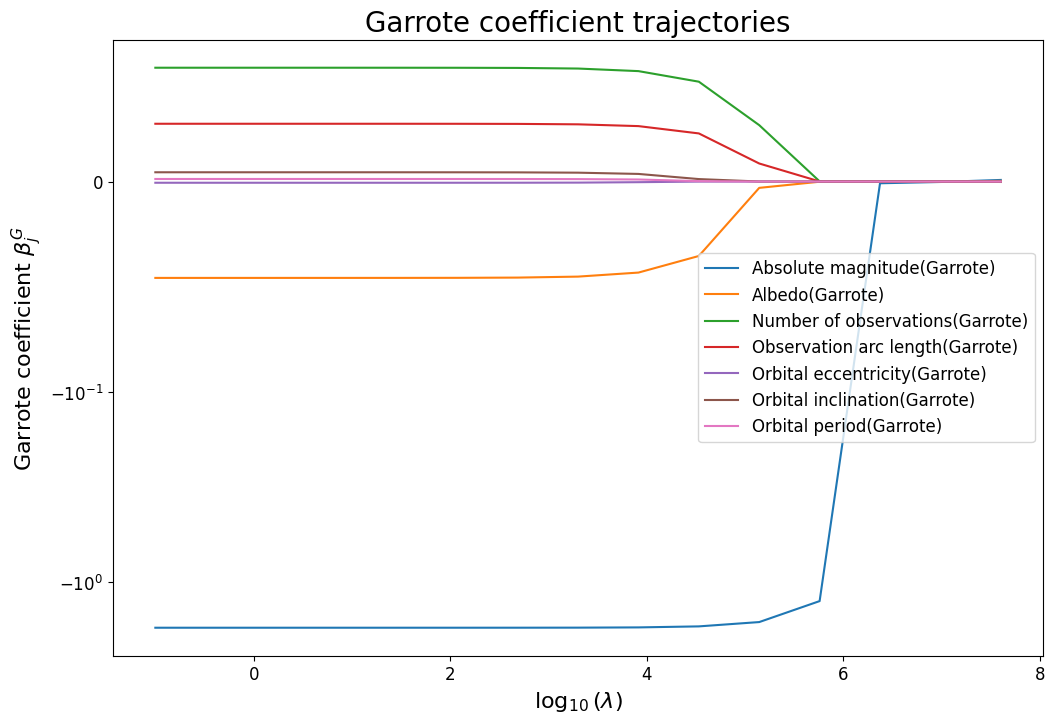

In [12]:
# S_lambda set
S_lambd = np.logspace(-1, 7.6, 15)

# record the parameters of each lambda
garrote_list = []

# train models of different lambda and record all the coeffient
for lambd in S_lambd:
    beta_G, beta_LS, g, loss_history, epochs_list = train_garrote(X_train_std, y_train, lambd=lambd)
    garrote_list.append(beta_G)
all_garrote = np.vstack(garrote_list)

# plot each feature
fig, ax = plt.subplots(figsize=(12, 8))
for param in range(all_garrote.shape[1]):
    ax.plot(np.log10(S_lambd), all_garrote[:, param], label=features[param]+"(Garrote)")

plt.yscale("symlog", linthresh=0.1)
plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"Garrote coefficient ${\beta}_j^{G}$")
plt.title("Garrote coefficient trajectories")
plt.legend()
plt.show()

### Discussion

From the plot, we can see due to the penalty, as $\lambda$ increases, the Garrote coefficients $\hat{\boldsymbol\beta}^{G}$ are progressively going down to zero, and give a sparse solution, which is similar to LASSO and shows how the feature selection works by L1 regularization.

In terms of feature importance, Absolute magnitude is the most important feature, followed by Number of observations and Albedo. The three least important features are Orbital eccentricity, Orbital inclination, and Orbital period. Even when $\lambda$ is small, the coefficients of these three features are already close to zero, and as λ increases, they are the first to be driven to zero.

Absolute magnitude is the most important because its coefficient has the largest absolute value and is the last to become zero. Number of observations is the same case.

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

In [13]:
# from week 4 notebook
def T_fold_split(num_samples, num_folds):
    """
    Splits the dataset indices into `num_folds` folds for cross-validation without shuffling

    Parameters:
        num_samples (int): The total number of samples in the dataset.
        num_folds (int): The number of folds for cross-validation.

    Returns:
        fold (list[np.array]): A list of numpy arrays containing the indices defining the validation set for one fold.
    """
    fold_size = num_samples // num_folds
    indices = np.arange(num_samples)
    folds = [indices[i * fold_size : (i + 1) * fold_size] for i in range(num_folds)]
    return folds

def T_fold_evaluation(X, y, num_folds, S_lambd):
    """
    Performs T-fold cross-validation on the given dataset to test the stability of Garrote on different lambda.

    Parameters:
        X (np.array): training data before standardise
        y (np.array): label
        num_folds (int): The number of folds for cross-validation.
        S_lambd (list): A list of regularisation strength values to evaluate.

    Returns:
        d_list (list): average absolute difference
    """
    N, p = X.shape
    assert N == y.shape[0]

    folds = T_fold_split(N, num_folds)
    d_list = []
    for j, lambd in enumerate(S_lambd):
        val_mse_list = []
        for i, val_indice in enumerate(folds):
            # Define the training and validation sets
            train_indices = np.setdiff1d(np.arange(N), val_indice)
            X_train, y_train = X[train_indices], y[train_indices]
            X_val, y_val = X[val_indice], y[val_indice]

            # standardise
            X_train_std = standardise(X_train)
            X_val_std = standardise(X_val, X_train_=X_train)

            N_val = X_val.shape[0]
            assert N_val == len(val_indice)

            # train
            beta_G, beta_LS, _, _, _ = train_garrote(X_train_std, y_train, lambd=lambd)

            # compute mse
            mse = np.mean((y_val - X_val_std @ beta_G - beta_LS[0]) ** 2)
            val_mse_list.append(mse)

        # compute the average absolute difference
        sumation = 0
        for t in range(1, num_folds):
            sumation += abs(val_mse_list[t] - val_mse_list[t - 1])
        sumation /= num_folds - 1
        d_list.append(sumation)

    return d_list

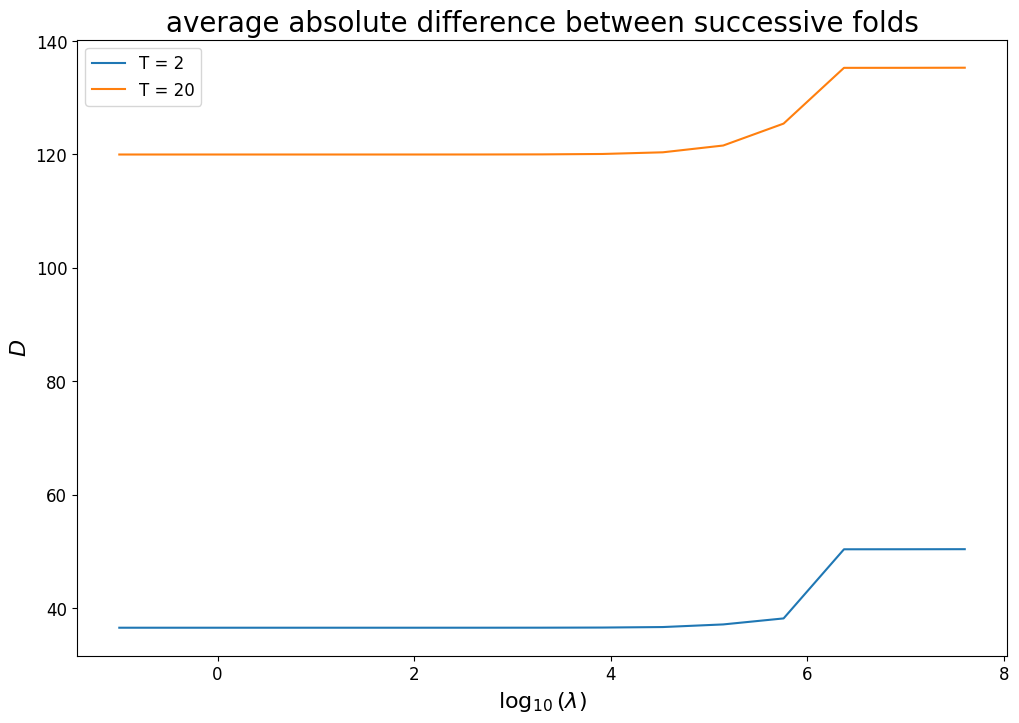

In [14]:
T_list = [2, 20]

fig, ax = plt.subplots(figsize=(12, 8))
for T in T_list:
    d_list = T_fold_evaluation(X_train, y_train, T, S_lambd)
    ax.plot(np.log10(S_lambd), d_list, label=r"T = "+f"{T}")

plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"$D$")
plt.title("average absolute difference between successive folds")
plt.legend()
plt.show()

### Discussion

$$
D = \frac{1}{T - 1} \sum_{t=2}^{T}|{MSE}_{t} - {MSE}_{t - 1}|
$$
is the average absolute difference in the validation MSE between successive folds. A smaller $D$ indicates a more stable model because it means replacing a small portion of the training data does not cause large change in out-of-sample performance.

From the plot, when $\lambda < 10^6$, the two curves are relatively flat. This indicates that the Garrote validation MSE is not sensitive to small changes in the training set, so the model is stable. As $\lambda$ increases to larger values, $D$ starts to rise, which means the model is less stable. 

The reason is that the L1 regularization dominates when $\lambda$ gets larger, makes coefficients go to zero. This basicly makes the prediction a constant (interception of OLS), and causes big bias. So different distribution of validation set have huge difference in the MSE(consider $y_{true} - y_{prediction}$ where $y_{true}$ has different value and $y_{prediction}$ is constant). This makes the model less stable.

Comparing T=2 and T=20, the overall $D$ for T=20 is larger. This is because the size of validation set when T=20 is smaller, so it becomes sensitive to those bad prediciton and cause the a big variance. So the difference $|{MSE}_{t} - {MSE}_{t - 1}|$ is bigger than the case T=2.

<a name="task-13"></a>

## (1.3) [(index)](#index-task-13)

In [15]:
# from week 1 notebook
def minimize_ls_huber(X, y, lambd, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    """
    This function estimates the regression parameters with the relaxed version
    of LASSO regression using the gradient-descent algorithm to find the optimal
    solution.
    Args:
    X (np.array): The augmented data matrix with shape (N, p ).
    y (np.array): The response column with shape (N, 1).
    lambd (float): The multiplier of the relaxed L1 term.
    n_iters (int): Number of gradient descent iterations.
    step_size (float): The step size in the updating step.
    """

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    X_aug = np.hstack((np.ones((N, 1)), X))
    # Precomputed products to avoid redundant computations.
    XX = X_aug.T @ X_aug
    Xy = X_aug.T @ y
    # Initialize beta params with zeros
    beta = np.zeros(p + 1)

    for i in range(n_iters):
        # Compute the gradient of the relaxed LASSO, Huber.
        grad_c = grad_huber(beta, c_huber)

        # Intercept term is not involved in the regularisation.
        grad_c[0] = 0 ## <-- EDIT THIS LINE

        # Compute the gradient of the regularised loss.
        grad = (2 / N) * (XX @ beta - Xy) + lambd * grad_c ## <-- EDIT THIS LINE

        # Update beta
        beta = beta - step_size * grad ## <-- EDIT THIS LINE

    return beta

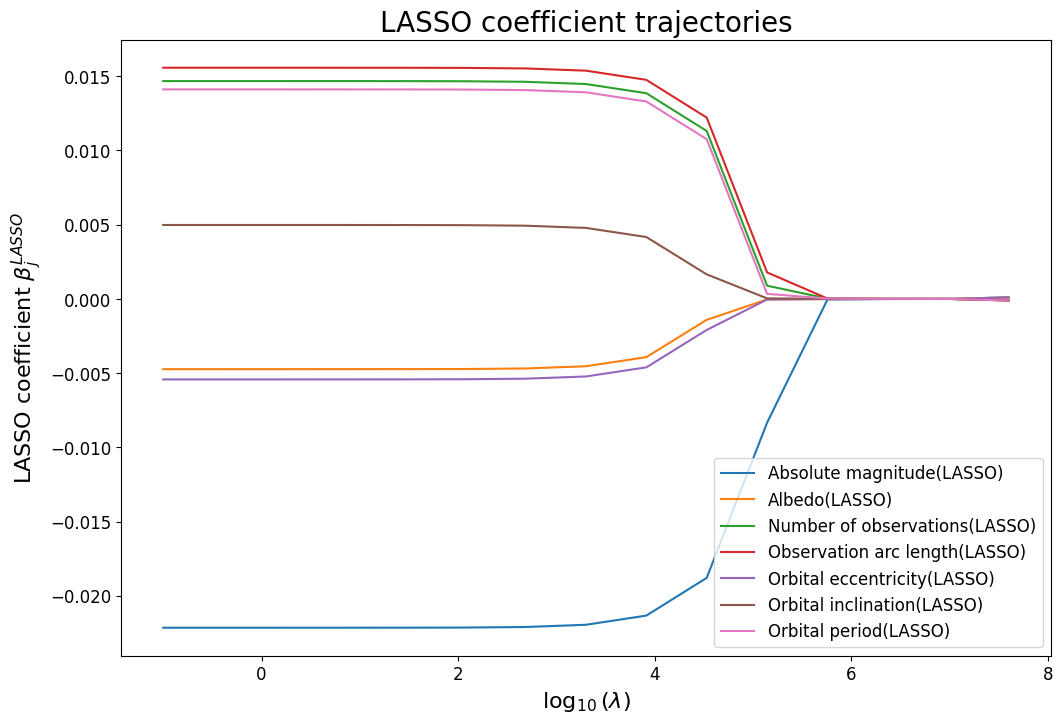

In [16]:
# record the parameters of each lambda
lasso_list = []

# train models of different lambda
for lambd in S_lambd:
    beta_lasso = minimize_ls_huber(X_train_std, y_train, lambd=lambd)
    beta_lasso_without_intercept = beta_lasso[1:]
    lasso_list.append(beta_lasso_without_intercept)
all_lasso = np.vstack(lasso_list)

# plot
fig, ax = plt.subplots(figsize=(12, 8))
for j in range(all_lasso.shape[1]):
    ax.plot(np.log10(S_lambd), all_lasso[:, j], label=features[j]+"(LASSO)")

plt.xlabel(r"$\log_{10}(\lambda)$")
plt.ylabel(r"LASSO coefficient ${\beta}_j^{LASSO}$")
plt.title("LASSO coefficient trajectories")
plt.legend()
plt.show()

### Comparison with Garrote
The result is a little different compared to Garrote. In LASSO, Absolute magnitude is still the most important feature, but Observation arc length becomes the secont important feature, and Number of observation becomes to the third. The third import feature in Garrote are less important in LASSO. Also, in LASSO, there is no feature very close to 0 when $\lambda$ is small which is unlike Garrote.

### Bootstrapping without replacement

Following the instructions, we use sampling without replacement.

In [17]:
def bootstrap_feature_selection(X, y, N_prime, lambd, B=100, n_iters=10000, step_size=1e-7, c_huber=1e-4):
    """
    Bootstrap on feature selection.

    Parameters:
        X (np.array): data
        y (np.array): label
        N_prime (int): sample size
        lambd (float): regularisation strength value
        B (int): times of bootstrap
        n_iters (int): number of iterations
        step_size (float): step size of gradient descent
        c_huber (float): smooth parameter

    Returns:
        np.array: probability of choosing each feature
    """    
    N, p = X.shape
    training_indices = np.arange(N)
    selection_counts = np.zeros(p)

    for b in range(B):
        # Bootstrapping
        indices = rng.choice(training_indices, size=N_prime, replace=False)
        X_sample = X[indices, :]
        y_sample = y[indices]

        # train lasso regressor
        beta_lasso = minimize_ls_huber(X_sample, y_sample, lambd, n_iters, step_size, c_huber)
        beta_lasso = beta_lasso[1:]

        # drop feature whose prob < 0.001
        selected = np.abs(beta_lasso) > 0.001
        selection_counts += selected

    return selection_counts / B

In [18]:
def plot_prob_trajectory(N_prime, S_lambd):
    """
    plot the trajectory of the selected probability

    Parameters:
        N_prime (int): size of bootstrap sample
        S_lambd (np.array): lambda set

    Returns:
        all_prob (np.array): record the probability of each lambda and each feature
    """
    prob_list = []

    # get prob of different lambda
    for lambd in S_lambd:
        prob_lasso = bootstrap_feature_selection(X_train_std, y_train, N_prime, lambd=lambd, B=100)
        prob_list.append(prob_lasso)
    all_prob = np.vstack(prob_list)

    # plot
    fig, ax = plt.subplots(figsize=(12, 8))
    for j in range(all_prob.shape[1]):
        ax.plot(np.log10(S_lambd), all_prob[:, j], label=features[j]+" Probability")

    plt.xlabel(r"$\log_{10}(\lambda)$")
    plt.ylabel(r"Feature Probability")
    plt.title(f"LASSO selection trajectory, N' = {N_prime}")
    plt.legend()
    plt.show()

    return all_prob

def plot_prob_bar(N_prime, all_prob, index):
    """
    plot the bar plot of the probability of a specific lambda

    Parameters:
        all_plot (np.array): the probability of each lambda and each feature
        index (int): index 
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    prob_lasso = all_prob[index, :]

    # plot
    ax.bar(features, prob_lasso)
    plt.xlabel('Features')
    plt.ylabel('selection probability')
    plt.title(f"LASSO selection bar, N' = {N_prime}")
    plt.xticks(rotation=45)
    plt.show()

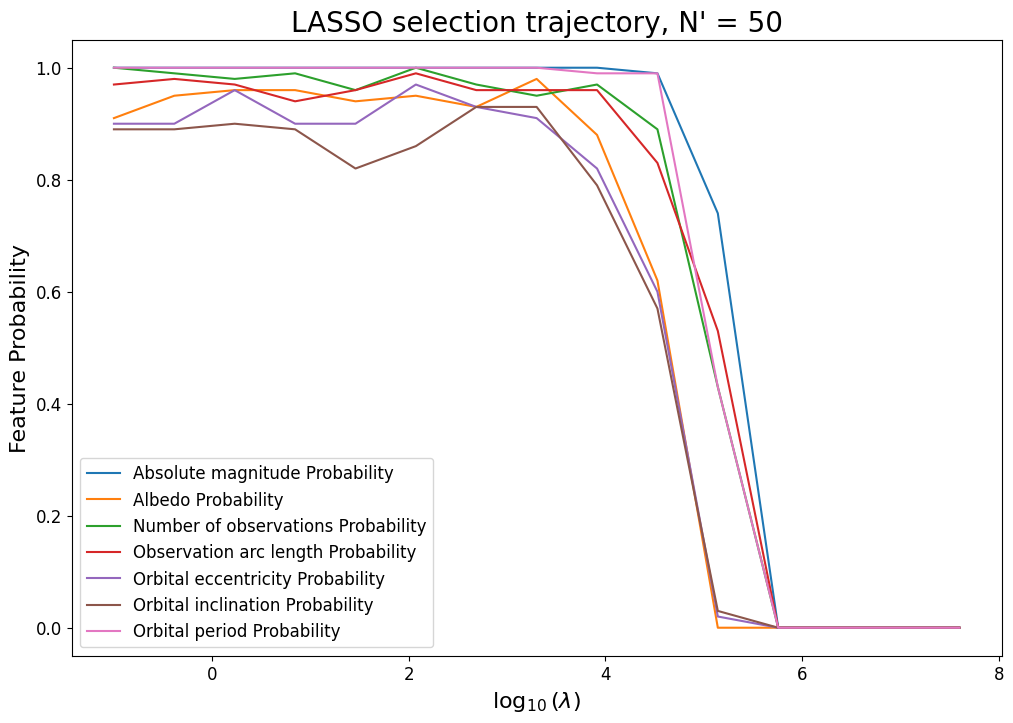

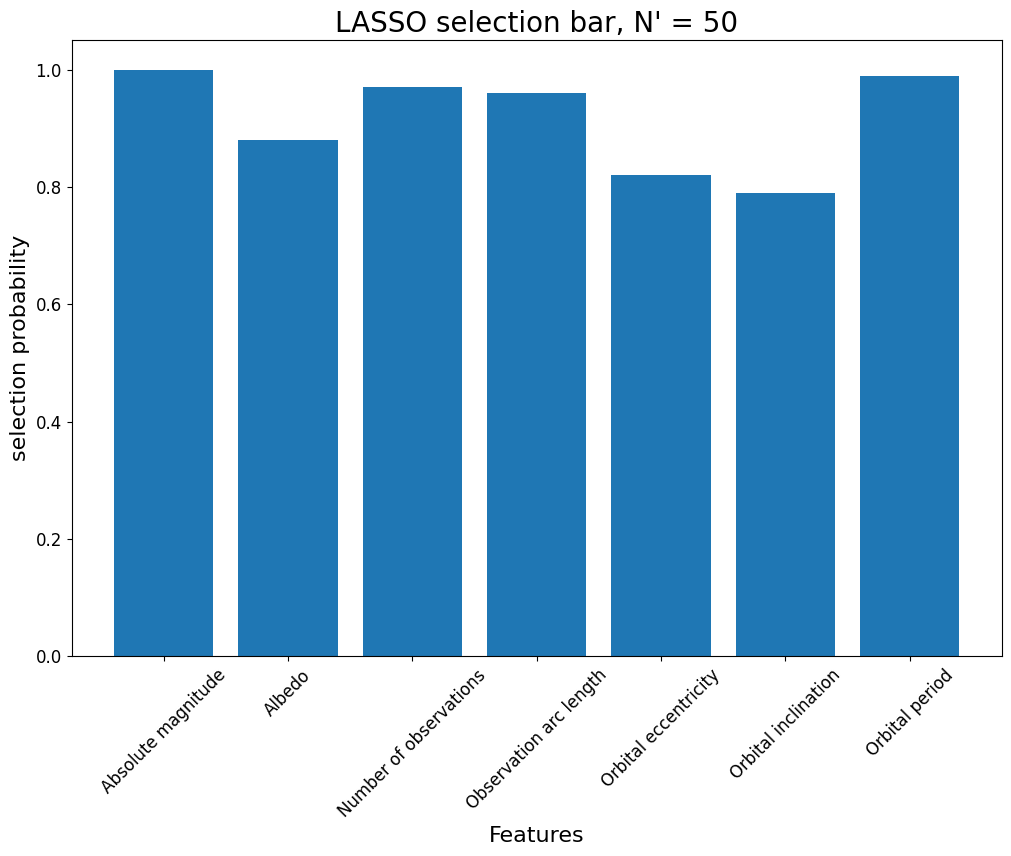

In [19]:
all_prob_50 = plot_prob_trajectory(50, S_lambd)
plot_prob_bar(50, all_prob_50, 8)

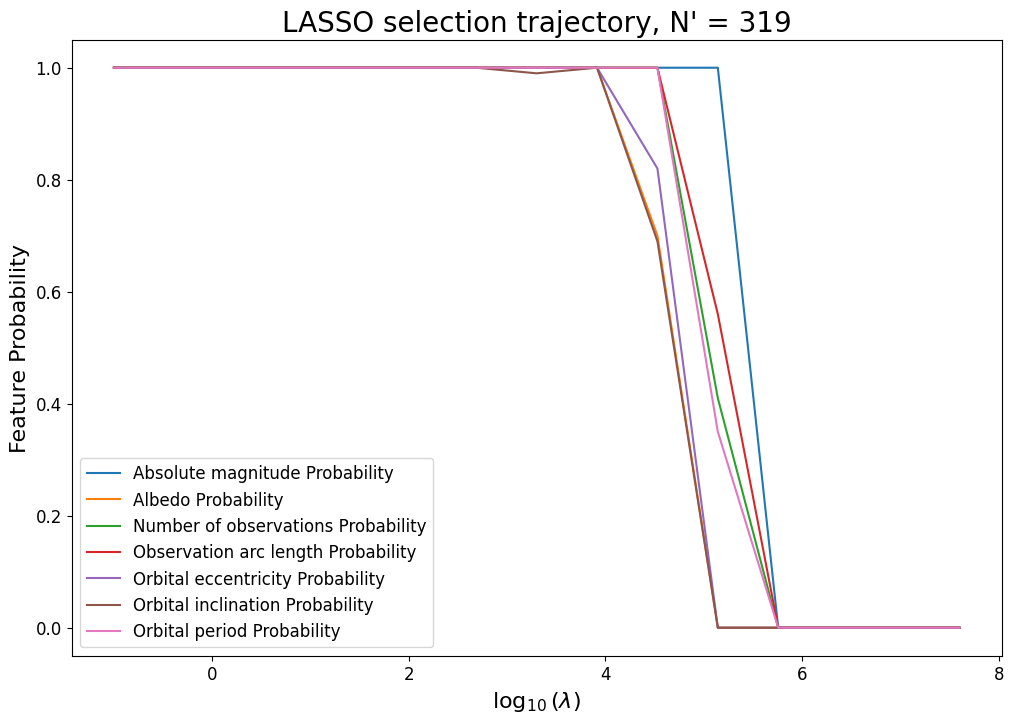

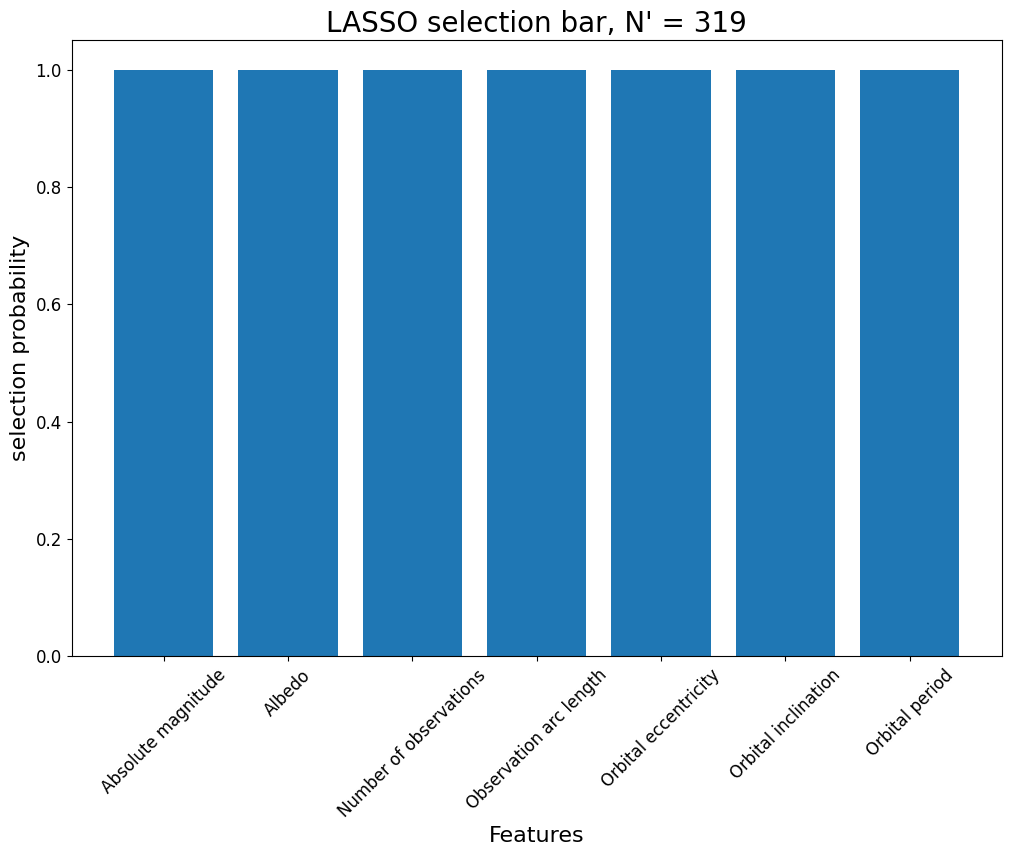

In [20]:
all_prob_half = plot_prob_trajectory(X_train_std.shape[0] // 2, S_lambd)
plot_prob_bar(X_train_std.shape[0] // 2, all_prob_half, 8)

### Discussion

Selection probability close to 1 indicates that the feature is stably selected by LASSO under small change of the training data, while a value near 0 means the feature selection is unstable or the coefficient is easily eliminated by the penalty.

Comparing sample sizes, $N' = N^{train}/2$ is generally more stable than $N' = 50$ (probabilities closer to 0 or 1, with sharper transitions), because larger samples reduce the variance of coefficient estimates. With $N' = 50$, noise is higher, and coefficients fluctuate more around the threshold, leading to less stable selection.


<a name="task-14"></a>

## (1.4) [(index)](#index-task-14)

From chapter 5, 
$$
Importance = | M^0 - M_{j \text{permuted}}^0 |
$$

where $M^0$ is the metric of performance of the tree on $ X^{OOB} $, $ M_{j \text{permuted}}^0 $ is the metric on this version of $X^{OOB}$ with the values at column j permuted.

we first define a metric $R^2$

In [21]:
# from week 5 notebook
def compute_r2(y_true, y_pred):
    """
    R^2 score to assess regression performance.
    """

    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)
    y_bar = y_true.mean()

    ss_tot = ((y_true - y_bar)**2).sum()
    ss_res = ((y_true - y_pred)**2).sum()
    return 1 - (ss_res/ss_tot)

In [22]:
def ls_importance(X_train, y_train, X_test, y_test):
    """
    Compute the feature importance via ols

    Parameters:
        X_train (np.array): training data
        y_train (np.array): training label
        X_test (np.array): test data
        y_test (np.array): test label

    Returns:
        importance (list): importance of each feature
    """
    # train ols
    beta_ls = fit_ols(X_train, y_train)

    # calculate M^0
    X_test_aug = np.hstack((np.ones((X_test.shape[0], 1)), X_test))
    y_test_pred_base = X_test_aug @ beta_ls
    r2_baseline = compute_r2(y_test, y_test_pred_base)

    importance = []
    p = X_test.shape[1]

    # calculate the importance of each feature
    for j in range(p):
        # permute the j-th column
        X_test_shuffled = X_test.copy()
        rng.shuffle(X_test_shuffled[:, j])

        # metric on permuted version of X^OOB
        X_test_shuffle_aug = np.hstack((np.ones((X_test.shape[0], 1)), X_test_shuffled))
        y_test_pred_shuffled = X_test_shuffle_aug @ beta_ls
        r2_shuffled = compute_r2(y_test, y_test_pred_shuffled)

        importance.append(abs(r2_baseline - r2_shuffled))

    importance = np.array(importance)
    max_value = np.max(importance)
    importance /= max_value

    return importance * 100

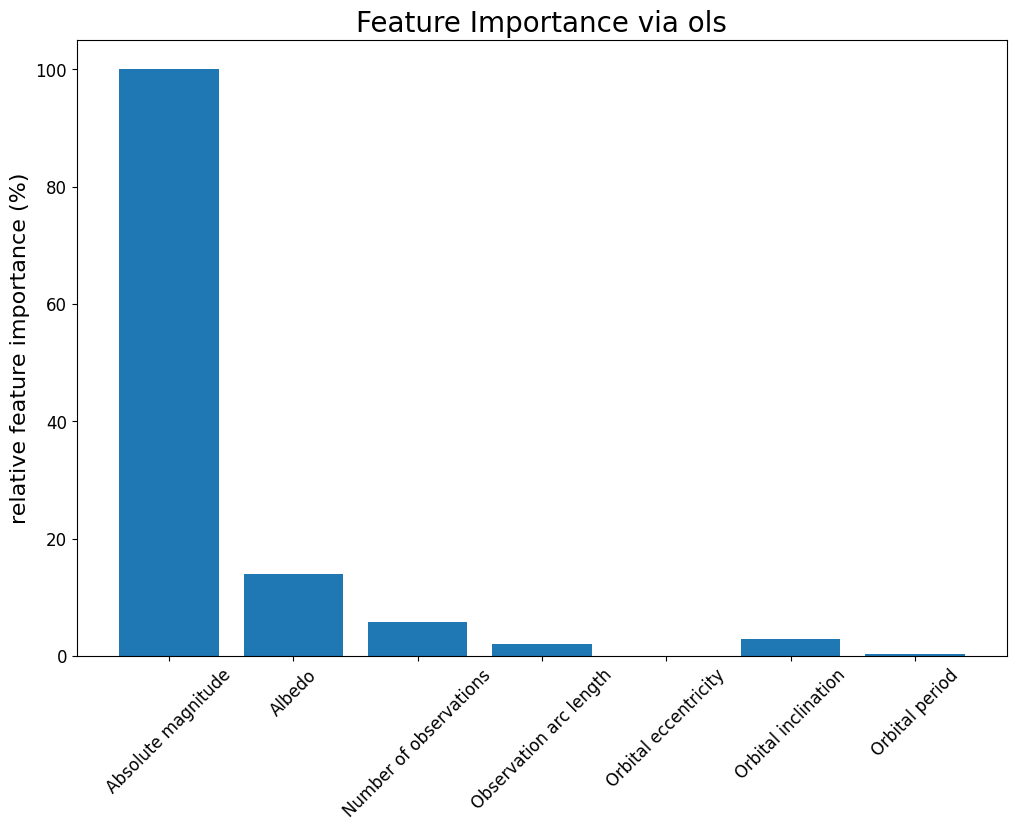

In [23]:
importance = ls_importance(X_train_std, y_train, X_test_std, y_test)

# plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(features, importance)
plt.ylabel('relative feature importance (%)')
plt.title('Feature Importance via ols')
plt.xticks(rotation=45)
plt.show()

Larger $| M^0 - M_{j \text{permuted}}^0 |$ means the metric change a lot when we destroy the j-th feature, so the model relies more on this feature. From the plot, Absolute magnitude has the biggest importance and it is significantly more important than the feature with second big importance Albedo. Number of observations is the third important feature. The permutation on the other features causes very few impact on the model performance.

In all task in task1, Absolute magnitude is always the most important or easiest to be selected. However the other positions are taken by different features. And both importance via permutation of ols and Garrote thinks Orbital eccentricity, Orbital inclination, and Orbital period are three least important features.

In Garrote, the coefficients associated with the most predictive variables remain non-zero over a wider range of $\lambda$. Similarly, in LASSO feature selection, more important variables tend to have higher selection probabilities and remain selected until larger $\lambda$.

<a name="task-2"></a>

# Task 2: Non-linear regression with Kernel Ridge Regression [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

In [24]:
# from week 1 notebook
def fit_ridge(X, y, penalty):
    """
    X: N x p matrix of training inputs
    y: N x 1 vector of training targets/observations
    returns: maximum likelihood parameters ((p + 1),)
    """
    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    X_aug = np.hstack([np.ones((N,1)), X]) # augmented training inputs of size N x (p + 1)
    N_aug, p_aug = X_aug.shape
    I = np.identity(p_aug)
    I[0] = 0.0 # penalty excludes the bias term.
    beta_ridge = np.linalg.solve(X_aug.T @ X_aug / N + penalty * I, X_aug.T @ y / N) ## <-- EDIT THIS LINE
    return beta_ridge.flatten()

def score_ridge(X_train, y_train, X_test, y_test, lambd=0.1):
    """
    compute the R^2 score of ridge model
    """
    beta_ridge = fit_ridge(X_train, y_train, penalty=lambd)
    N_test, p = X_test.shape
    X_test_aug = np.hstack([np.ones((N_test,1)), X_test])
    y_test_pred = X_test_aug @ beta_ridge
    r2 = compute_r2(y_test, y_test_pred)
    return r2

In [25]:
print("R^2 score on train set: ", score_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1))
print("R^2 score on test set: ", score_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1))

R^2 score on train set:  0.750465814764694
R^2 score on test set:  0.746036091143093


$$
\underset{\boldsymbol\beta}{\text{min}} \frac{1}{N^{\text{train}}} \| \boldsymbol y - \boldsymbol X \boldsymbol\beta \|^2 + \lambda \| \boldsymbol\beta \|^2
$$

$$
\underset{\boldsymbol\beta}{\text{min}} \frac{1}{N^{\text{train}}} \| \boldsymbol y - \boldsymbol\phi(\boldsymbol X )\boldsymbol\beta_{\phi} \|^2 + \lambda \| \boldsymbol\beta_{\boldsymbol\phi} \|^2
$$

introduce vector $\mathbf{u}$
$$
\boldsymbol{\beta}_{\boldsymbol \phi} = \sum_{i = 1}^{N} \boldsymbol\phi({\mathbf{x}^{(i)}}) u_i
$$

$$
\boldsymbol{\beta}_{\boldsymbol \phi} \cdot \boldsymbol\phi({\boldsymbol{X}^T}) = \mathbf{u}^T \mathbf{K}
$$

$$
\| \boldsymbol{\beta}_{\boldsymbol \phi} \|^2 = \boldsymbol{\beta}_{\boldsymbol \phi} \cdot \boldsymbol{\beta}_{\boldsymbol \phi} = \mathbf{u}^T \mathbf{K} \mathbf{u}
$$

optimise on $\mathbf{u}$
$$
\underset{\boldsymbol\beta}{\text{min}} \frac{1}{N^{\text{train}}} \| \boldsymbol y - \mathbf{K} \mathbf{u} \|^2 + \lambda \mathbf{u}^T \mathbf{K} \mathbf{u}
$$

$$
(\frac{\mathbf{K}^T\mathbf{K}}{N}+ \lambda \mathbf{K})\mathbf{u}^{*}_{\text{ridge}} = \frac{\boldsymbol K^T\boldsymbol y}{N}
$$

since $\mathbf{K}$ is symetric
$$
(\frac{\mathbf{K}}{N}+ \lambda \mathbf{I})\mathbf{u}^{*}_{\text{ridge}} = \frac{\boldsymbol y}{N}
$$

In [26]:
def polynomial_kernel_matrix(X1, X2, n=2, c=1):
    """
    Calculates the kernel matrix given the data.

    Parameters:
        X1, X2 (np.array): Two sets of input features.
        n, c (int): Hyperparameter in polinomial kernel.

    Returns:
        kernel (np.array): Kernel Matrix.
    """
    n1, m1 = X1.shape
    n2, m2 = X2.shape

    kernel = (X1 @ X2.T + c) ** n

    return kernel

def fit_kernel_ridge(X, y, penalty, n, c):
    """
    X: N x p matrix of training inputs
    y: N x 1 vector of training targets/observations
    penalty (float): regularisation strength
    n, c (int): Hyperparameter in polinomial kernel.
    returns: maximum likelihood parameters ((p + 1),)
    """
    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape

    # construct Kernel
    K = polynomial_kernel_matrix(X, X, n, c)
    I = np.identity(N)
    u_ridge = np.linalg.solve(K / N + penalty * I, y / N)
    assert u_ridge.shape[0] == N
    return u_ridge

def score_kernel_ridge(X_train, y_train, X_test, y_test, lambd, n, c):
    """
    compute the R^2 score of kernelised ridge model
    """
    u_ridge = fit_kernel_ridge(X_train, y_train, lambd, n, c)

    # construct Kernel
    K_test = polynomial_kernel_matrix(X_test, X_train, n, c)
    y_test_pred = K_test @ u_ridge
    r2 = compute_r2(y_test, y_test_pred)
    return r2

In [27]:
n, c = 2, 0
print(f"n = {n}, c = {c}, train set R^2 score: ", score_kernel_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1, n=n, c=c))
print(f"n = {n}, c = {c}, test set R^2 score: ", score_kernel_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1, n=n, c=c))
n, c = 2, 1
print(f"n = {n}, c = {c}, train set R^2 score: ", score_kernel_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1, n=n, c=c))
print(f"n = {n}, c = {c}, test set R^2 score: ", score_kernel_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1, n=n, c=c))
n, c = 3, 1
print(f"n = {n}, c = {c}, train set R^2 score: ", score_kernel_ridge(X_train_std, y_train, X_train_std, y_train, lambd=0.1, n=n, c=c))
print(f"n = {n}, c = {c}, test set R^2 score: ", score_kernel_ridge(X_train_std, y_train, X_test_std, y_test, lambd=0.1, n=n, c=c))

n = 2, c = 0, train set R^2 score:  0.7442772950233123
n = 2, c = 0, test set R^2 score:  0.6175788574986608
n = 2, c = 1, train set R^2 score:  0.953255587713263
n = 2, c = 1, test set R^2 score:  0.947743591512433
n = 3, c = 1, train set R^2 score:  0.9843306895540649
n = 3, c = 1, test set R^2 score:  0.9759929264269601


### Discussion (Task 2.1)

With $\lambda = 0.1$, ordinary ridge regression has similar $R^2$ on training and test data (0.75 and 0.74), which means the ridge regression performs not bad with limited overfitting.

The results above show that KRR performance depends strongly on the kernel parameters. With $(n = 2, c = 0)$, $R^{2}$ of test set is far smaller than the train set and shows a clear overfitting even though the $R^2$ of training set is not high, suggesting that this kernel parameter is not well matched to the data.

In contrast, letting $c = 1$ makes a large improvement. $(n = 2, c = 1)$ produces higher $R^{2}$ on both training and test sets, with a small difference, indicating improved fit without severe overfitting. Increasing the degree to $(n = 3, c = 1)$ further improves performance, again with training and test scores remaining close.

It shows that there are strong non-linearities in the data, and proper KRR setting can make a significant generalisation.

<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)

$$
k^{new}(\boldsymbol v, \boldsymbol z) = e ^ {-\frac{\| \boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z) \|^2}{\sigma}}
$$

$$
\| \boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z) \|^2 = 
(\boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z))^T (\boldsymbol{\phi}^{{P}}(\boldsymbol v) - \boldsymbol{\phi}^{{P}}(\boldsymbol z)) \\  
= \boldsymbol{\phi}^{{P}}(\boldsymbol v)^T \boldsymbol{\phi}^{{P}}(\boldsymbol v) + \boldsymbol{\phi}^{{P}}(\boldsymbol z)^T \boldsymbol{\phi}^{{P}}(\boldsymbol z) - 2 \boldsymbol{\phi}^{{P}}(\boldsymbol v)^T \boldsymbol{\phi}^{{P}}(\boldsymbol z) \\
= k^{P}(\boldsymbol v, \boldsymbol v) + k^{P}(\boldsymbol z, \boldsymbol z) - 2 k^{P}(\boldsymbol v, \boldsymbol z)
$$

$$
k^{new}(\boldsymbol v, \boldsymbol z) = e ^ {-\frac{k^{P}(\boldsymbol v, \boldsymbol v) + k^{P}(\boldsymbol z, \boldsymbol z) - 2 k^{P}(\boldsymbol v, \boldsymbol z)}{\sigma}}
$$

We first implement the RBF kernel and new kernel

In [28]:
# from week 4 notebooks
def rbf_kernel_matrix(X1, X2, sigma=20):
    """
    Calculates the kernel matrix given the data.

    Parameters:
        X1, X2 (np.array): Two sets of input features.
        sigma (float): Hyperparameter in Gaussian kernel.

    Returns:
        kernel (np.array): Kernel Matrix.
    """
    n1, m1 = X1.shape
    n2, m2 = X2.shape
    kernel = np.zeros((n1, n2))

    # Here we define a Gaussian Radial Basis Function Kernel
    for i in range(n1):
        exponent = np.linalg.norm(X1[i, :] - X2, axis=1) ** 2 ## <-- EDIT THIS LINE
        kernel[i,:] = np.exp(-exponent / sigma)

    return kernel

def new_kernel_matrix(X1, X2, sigma=20, n=2, c=1):
    """
    Calculates the kernel matrix given the data.

    Parameters:
        X1, X2 (np.array): Two sets of input features.
        sigma, n, c: Hyperparameter in new kernel.

    Returns:
        kernel (np.array): Kernel Matrix.
    """
    n1, m1 = X1.shape
    n2, m2 = X2.shape

    k_P_v = (X1 @ X1.T + c) ** n
    k_P_z = (X2 @ X2.T + c) ** n
    k_P_vz = (X1 @ X2.T + c) ** n

    exponent = np.zeros((n1, n2))
    for i in range(n1):
        for j in range(n2):
            exponent[i, j] = k_P_v[i, i] + k_P_z[j, j] - 2 * k_P_vz[i, j]

    kernel = np.exp(-exponent / sigma)
    return kernel

Then we implement the general version of the kernel ridge and scoring

In [29]:
def fit_gernal_kernel_ridge(X, y, penalty, kernal_type, sigma=20, n=2, c=1):
    """
    X: N x p matrix of training inputs
    y: N x 1 vector of training targets/observations
    penalty (float): regularisation strength
    kernal_type (str): type of kernal matrix
    sigma, n, c: Hyperparameter in polinomial kernel.
    returns: maximum likelihood parameters ((p + 1),)
    """
    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape

    # construct Kernel
    if kernal_type == "polinomial":
        K = polynomial_kernel_matrix(X, X, n=n, c=c)
    elif kernal_type == "rbf":
        K = rbf_kernel_matrix(X, X, sigma=sigma)
    elif kernal_type == "new":
        K = new_kernel_matrix(X, X, sigma=sigma, n=n, c=c)

    I = np.identity(N)
    u_ridge = np.linalg.solve(K / N + penalty * I, y / N)
    assert u_ridge.shape[0] == N
    return u_ridge.flatten()

def score_gernal_kernal_ridge(X_train, y_train, X_test, y_test, lambd, kernel_type, sigma=20, n=2, c=1):
    """
    compute the R^2 score of kernelised ridge model
    """
    u_ridge = fit_gernal_kernel_ridge(X_train, y_train, lambd, kernel_type, sigma, n, c)

    # construct Kernel
    if kernel_type == "polinomial":
        K_test = polynomial_kernel_matrix(X_test, X_train, n=n, c=c)
    elif kernel_type == "rbf":
        K_test = rbf_kernel_matrix(X_test, X_train, sigma=sigma)
    elif kernel_type == "new":
        K_test = new_kernel_matrix(X_test, X_train, sigma=sigma, n=n, c=c)
    y_test_pred = K_test @ u_ridge
    r2 = compute_r2(y_test, y_test_pred)
    return r2

Finally we plot the 3d graph

In [78]:
def plot_krr_3d(X_train, y_train, S_lambd, sigma=20, n=2, c=1, kernels=("polinomial", "rbf", "new")):
    """
    Plot KRR 3D surfaces.
    """
    # use only first two features
    X_train_2d = X_train[:, :2]

    # create common grid
    x1_min, x1_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
    x2_min, x2_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 30),
        np.linspace(x2_min, x2_max, 30)
    )
    X_grid = np.c_[xx1.ravel(), xx2.ravel()]

    n_rows = len(kernels)
    n_cols = len(S_lambd)

    # plot
    fig = plt.figure(figsize=(12, 18))
    for col, lambd in enumerate(S_lambd):
        for row, kernel_type in enumerate(kernels):
            ax = fig.add_subplot(n_rows, n_cols, row * n_cols + col + 1, projection="3d")

            # fit u
            u_ridge = fit_gernal_kernel_ridge(X_train_2d, y_train, lambd, kernel_type, sigma, n, c)

            # kernel matrix between grid and train
            if kernel_type == "polinomial":
                K_grid = polynomial_kernel_matrix(X_grid, X_train_2d, n, c)
            elif kernel_type == "rbf":
                K_grid = rbf_kernel_matrix(X_grid, X_train_2d, sigma)
            elif kernel_type == "new":
                K_grid = new_kernel_matrix(X_grid, X_train_2d, sigma, n, c)

            y_grid_pred = (K_grid @ u_ridge).reshape(xx1.shape)

            # scatter train + surface
            ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], y_train, color="red")
            ax.plot_surface(xx1, xx2, y_grid_pred, alpha=0.4, cmap="viridis")
            ax.view_init(elev=20, azim=-60)
            ax.set_ylabel("Albedo")
            ax.set_xlabel("Absolute Magnitude")
            ax.set_zlabel("Diameter")
            ax.set_title(f"Kernel: {kernel_type}, lam={lambd}")
    plt.show()


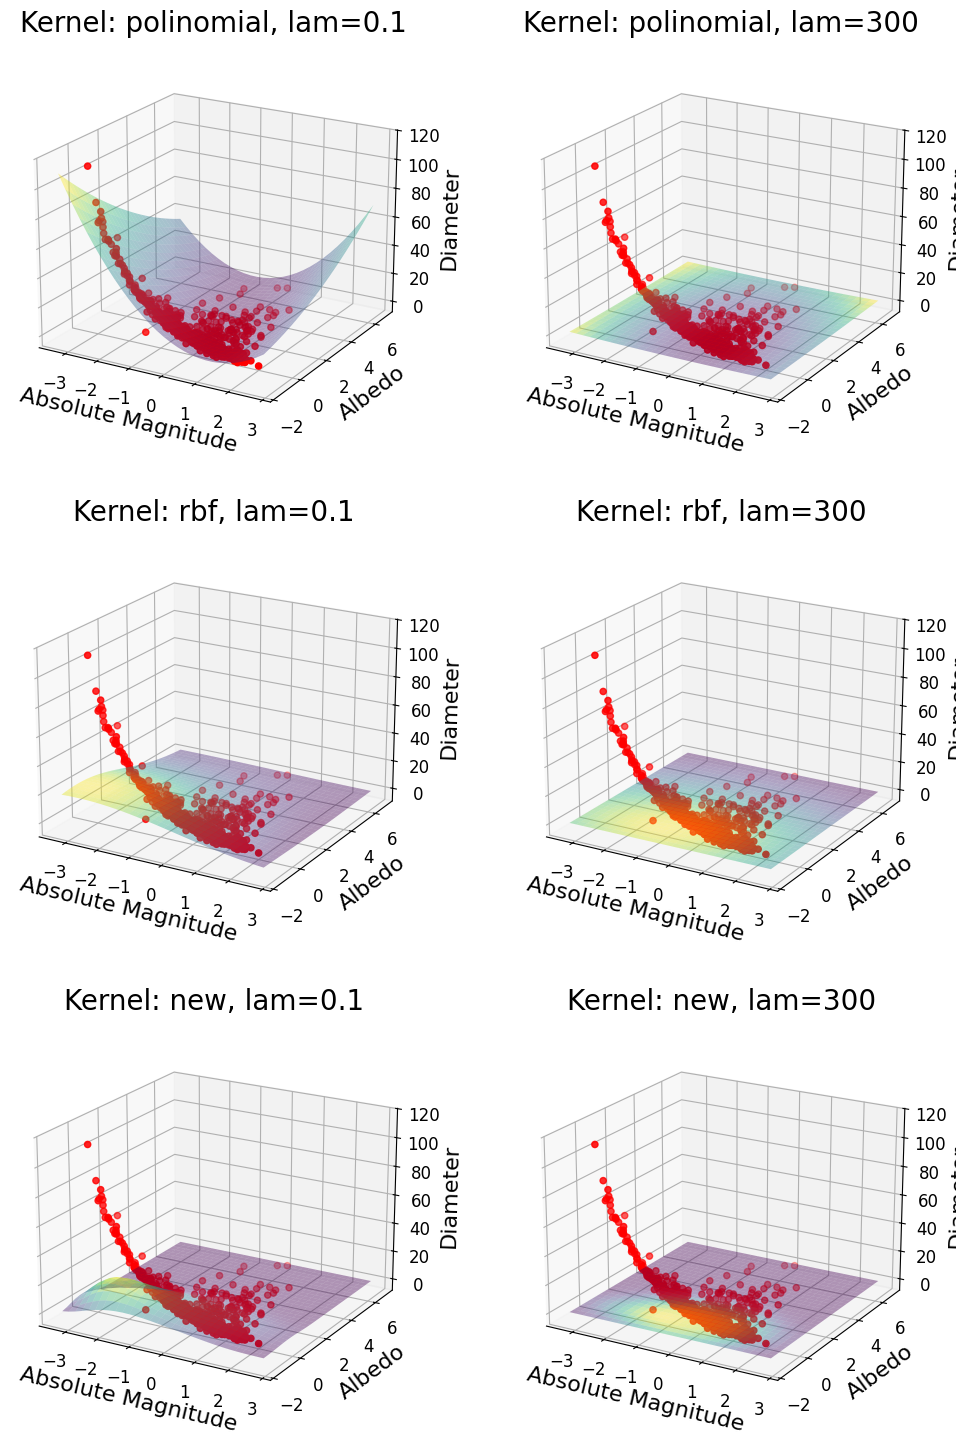

In [79]:
plot_krr_3d(X_train_std, y_train, S_lambd=[0.1, 300])

In [33]:
for lambd in [0.1, 300]:
    for kernel_type in ["polinomial", "rbf", "new"]:
        print(f"lambda = {lambd}, kernel type: {kernel_type}, R2 score: ",
              score_gernal_kernal_ridge(X_train_std[:, :2], y_train, X_train_std[:, :2], y_train, lambd, kernel_type),
              "\n")

lambda = 0.1, kernel type: polinomial, R2 score:  0.9503704611002955 

lambda = 0.1, kernel type: rbf, R2 score:  0.4219633288626309 

lambda = 0.1, kernel type: new, R2 score:  0.3960551367124596 

lambda = 300, kernel type: polinomial, R2 score:  -0.7456085793543004 

lambda = 300, kernel type: rbf, R2 score:  -0.7803514683772905 

lambda = 300, kernel type: new, R2 score:  -0.7820365661651816 



<a name="task-3"></a>

# Task 3: Classification with the Multi-Layer Perceptron [(index)](#index-task-3)

First we use the functions of the week 5 notebook.

In [157]:
# from week 5 notebook
def mse_loss(y_true, y_pred):
    """Compute MSE-loss

    Parameters:
        y_true: ground-truth array, with shape (K, )
        y_pred: predictions array, with shape (K, )

    Returns:
        loss (float): MSE-loss
    """
    assert y_true.size == y_pred.size, "Ground-truth and predictions have different dimensions."

    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)

    # Compute MSE loss
    loss = np.mean((y_true - y_pred) ** 2, keepdims=True) ## <-- EDIT THIS LINE
    return loss

def grad_mse_loss(y_true, y_pred):
    """Compute gradient of MSE-loss

    Parameters:
        y_true: ground-truth values, shape: (K, ).
        y_pred: prediction values, shape: (K, ).

    Returns:
        grad (np.ndarray): Gradient of MSE-loss, shape: (K, ).
    """
    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)

    # Compute gradient of MSE loss
    grad = 2.0 * (y_pred - y_true) / y_true.size ## <-- EDIT THIS LINE
    return grad

In [158]:
# from week 5 notebooks
def dense(X, W, b):
    """Full-connected MLP layer.

    Parameters:
        X (np.ndarray): K x h_in array of inputs, where K is the batch size and h_in is the input dimension.
        W (np.ndarray): h_out x h_in array for weights matrix parameters, where h_out is the output dimension.
        b (np.ndarray): Length h_out 1-D array for bias parameters

    Returns:
        a (np.ndarray): K x h_out array of pre-activations
    """
    a = X @ W.T + b ## <-- EDIT THIS LINE
    return a

def relu_activation(a):
    """ReLU activation function.

    Parameters:
        a: K x h_out array of pre-activations

    Returns:
        h: K x h_out array of post-activations
    """
    # compute post-activations
    h = np.maximum(a, 0.)  ## <-- EDIT THIS LINE
    return h

def grad_relu_activation(a):
    """Gradient of ReLU activation function.

    Parameters:
        a: K x h_out array of pre-activations

    Returns:
        grad: K x h_out gradient array of post-activations
    """
    # compute gradient
    grad = np.where(a < 0, 0, 1) ## <-- EDIT THIS LINE
    return grad

def softmax(a, axis=1):
    """
    softmax on prediction
    
    Parameters:
        a: K x num_class array of logits

    Returns:
        K x num_class array of probabilities
    """
    exp = np.exp(a)
    return exp / np.sum(exp, axis=axis, keepdims=True)

# A lookup table for activation functions by their names.
activation_table = {
    "relu": relu_activation,
    # Identity function.
    "identity": lambda x: x
}

# A lookup table for gradient of activation functions by their names.
grad_activation_table = {
    "relu": grad_relu_activation,
    # Identity function gradient.
    "identity": lambda x: np.ones_like(x)
}

In [159]:
# from week 5 notebook
class MLP:
    """
    This class represents a Multi-Layer Perceptron (MLP), that we are going
    to use to encapsulate two components:
        1. layers: the sequence of layers, where each layer is stored in
            a dictionary in the format {"W": np.ndarray, "b": np.ndarray},
            where "W" points to the weights array, and "b" points to
            the bias vector.
        2. rng: a pseudo random number generator (RNG) initialised to generate
            the random weights in a reproducible manner between different
            runtime sessions.
    This class is also shipped with methods that perform essential operations
    with a MLP, including:
        - add_layers: which creates a new layer with specified dimensions.
        - predict: applies the MLP forward pass to make predictions and produces
            a computational graph for the forward pass that can be used to
            compute gradients using backpropagation algorithm.
        in addition to other light functions that return simple statistics about
        the MLP.
    """
    def __init__(self, seed=2):
        self.layers = []
        self.rng = np.random.default_rng(seed)

    def n_parameters(self):
        """Return the total number of parameters of weights and biases."""
        return sum(l["b"].size + l["W"].size for l in self.layers)

    def n_layers(self):
        """Return current number of MLP layers."""
        return len(self.layers) + 1 if len(self.layers) > 0 else 0

    def layer_dim(self, index):
        """Retrieve the dimensions of the MLP layer at `index`."""
        return self.layers[index]["W"].shape

    def add_layer(self, in_dim, out_dim, activation="identity"):
        """Add fully connected layer to MLP.

        Parameters:
            in_dim (int): The input dimension of the layer.
            out_dim (int): The output dimension of the layer.
            activation (str): The activation function name.
        """
        # check if input-dimension matches output-dimension of previous layer
        if self.n_layers() > 0:
            last_out_dim, _ = self.layer_dim(-1)
            assert in_dim == last_out_dim, f"Input-dimension {in_dim} does not match output-dimension {last_out_dim} of previous layer."

        # the first layer, in our convention illustrated, does not apply activation on the input features X.
        if self.n_layers() == 0:
            assert activation == "identity", "Should not apply activations on the input features X, use Identity function for the first layer."


        # store each layer as a dictionary in the list, as shown in the
        # attached diagram.
        self.layers.append({
            # only for debugging.
            "index": len(self.layers),
            # apply Glorot initialisation for weights.
            # hint: use self.rng.normal()
            "W": self.rng.normal(size=(out_dim, in_dim)) * np.sqrt(2. / (in_dim + out_dim)), ## <-- EDIT THIS LINE
            # initialise bias vector with zeros.
            "b": np.zeros(out_dim), ## <-- EDIT THIS LINE
            # store the activation function (as string)
            "activation": activation
        })

    def predict(self, X):
        """Apply the forward pass on the input X and produce prediction and the
        forward computation graph.

        Parameters:
            X (np.ndarray): Feature matrix.

        Returns:
            (np.ndarray, List[Dict[str, np.ndarray]]): A tuple of the
            predictions and the computation graph as a sequence of intermediate
            values through the MLP, specifically each layer will have a corresponding
            intermediate values {"a": np.ndarray, "h": np.ndarray}, as shown in the
            attached diagram above.
        """
        # We assume that we work with a batch of examples (ndim==2).
        if X.ndim == 1:
            # If one example passed, add a dummy dimension for the batch.
            X = X.reshape(1, -1)

        # store pre- and post-activations in list
        forward_pass = [{"index": 0, "a": X, "h": X}]

        # iterate through hidden layers
        for k in range(1, len(self.layers)):
            # compute pre-activations
            a = dense(forward_pass[-1]["h"], self.layers[k - 1]["W"], self.layers[k - 1]["b"]) ## <-- EDIT THIS LINE
            activation = activation_table[self.layers[k]["activation"]] ## <-- EDIT THIS LINE
            forward_pass.append({"index": k, "a" : a, "h" : activation(a)})

        y_hat = dense(forward_pass[-1]["h"], self.layers[-1]["W"], self.layers[-1]["b"]) ## <-- EDIT THIS LINE
        # predicted target is output of last layer
        return y_hat, forward_pass

Cross Entropy is
$$
CE = - \sum_{i=1}^{N^{\text{train}}} \sum_{q=0}^{Q-1} y_q^{(i)} \log p_q^{(i)}.
$$

calculate partial derivative with respect to $p_k^{(j)}$
$$
\frac{\partial CE}{\partial p_k^{(j)}}
= - \sum_{i=1}^{N^{\text{train}}} \sum_{q=0}^{Q-1} y_q^{(i)} \frac{\partial}{\partial p_k^{(j)}} \log p_q^{(i)}.
$$

Only when $(i,q)=(j,k)$, $\log p_q^{(i)}$ relies on $p_k^{(j)}$, so
$$
\frac{\partial}{\partial p_k^{(j)}} \log p_q^{(i)}
=
\begin{cases}
\frac{1}{p_k^{(j)}}, & (i,q)=(j,k),\\[6pt]
0, & \text{otherwise}.
\end{cases}
$$

Therefore:
$$
\frac{\partial CE}{\partial p_k^{(j)}}
= - y_k^{(j)} \cdot \frac{1}{p_k^{(j)}}
= -\frac{y_k^{(j)}}{p_k^{(j)}}.
$$

So
$$
\frac{\partial CE}{\partial p^{(j)}} = -\, \frac{y^{(i)}}{p^{(i)}}
$$

let $i$ th sample logits is $z^{(i)}$, then
$$
p_q^{(i)}=\mathrm{softmax}(z^{(i)})_q
=\frac{e^{z_{q'}^{(i)}}}{\sum_{r=0}^{Q-1} e^{z_{q'}^{(i)}}}.
$$

so
$$
\frac{\partial p_q^{(i)}}{\partial z_k^{(i)}} = p_q^{(i)}\left(\mathbf{1}\{q=k\}-p_k^{(i)}\right).
$$


chain rule
$$
\frac{\partial CE}{\partial z_k^{(i)}}
=\sum_{q=0}^{Q-1}\frac{\partial CE}{\partial p_q^{(i)}}\frac{\partial p_q^{(i)}}{\partial z_k^{(i)}}
=\sum_{q=0}^{Q-1}\left(-\frac{y_q^{(i)}}{p_q^{(i)}}\right)\, p_q^{(i)}(\mathbf{1}_{q=k}-p_k^{(i)}).
$$

$$
\frac{\partial CE}{\partial z_k^{(i)}}
=-\sum_{q=0}^{Q-1} y_q^{(i)}(\mathbf{1}_{q=k}-p_k^{(i)})
= -y_k^{(i)} + p_k^{(i)}\sum_{q=0}^{Q-1}y_q^{(i)}.
$$

if $y^{(i)}$ is one-hot, $\sum_q y_q^{(i)}=1$
$$
\frac{\partial CE}{\partial z_k^{(i)}} = p_k^{(i)} - y_k^{(i)}
$$

$$
\frac{\partial CE}{\partial z^{(i)}} = p^{(i)} - y^{(i)}
$$

In [160]:
def cross_entropy_loss(y_true, y_prob):
    """Compute Cross Entropy loss

    Parameters:
        y_true: ground-truth array, with shape (K, num_class) one-hot
        y_pred: predictions array, with shape (K, num_class)

    Returns:
        loss (float): MSE-loss
    """
    assert y_true.shape == y_prob.shape
    loss = -np.sum(np.sum(y_true * np.log(y_prob), axis=1), keepdims=True)
    return loss

def grad_cross_entropy_loss(y_true, y_prob):
    """
    Gradient of the Cross Entropy loss with respect to logits
    """
    return y_prob - y_true

# from week 5 notebook
def backpropagate(layers, forward_pass, delta_output):
    """
    Apply the backpropagation algorithm to the MLP layers to compute the gradients starting from
    the output layer to the input layer, and starting the chain rule from the
    partial derivative of the loss function w.r.t the predictions $hat{y}$

    Parameters:
        layers (List[Dict[str, np.ndarray]]): The MLP sequence of layers, as shown in the diagrams.
        forward_pass (List[Dict[str, np.ndarray]]): The forward pass intermediate values for
            each layer, representing a computation graph.
        delta_output (np.ndarray): the partial derivative of the loss function w.r.t the
            predictions $hat{y}$, has the shape (K, 1), where K is the batch size.
    Returns:
        gradients (List[Dict[str, np.ndarray]]): The computed gradient using a structure symmetric in the layers, as shown
            in the diagrams.

    """
    # Create a list that will contain the gradients of all the layers.
    gradients = []

    # Initialise delta.
    delta = delta_output

    assert len(layers) == len(forward_pass), "Number of layers is expected to match the number of forward pass layers"

    # Iterate on layers backwardly, from output to input.
    # Calculate gradients w.r.t. weights and biases of each level and store in list of dictionaries.
    for layer, forward_computes in reversed(list(zip(layers, forward_pass))):   # zip iterates through pairs of layers and forward_pass
        assert forward_computes["index"] == layer["index"], "Mismatch in the index."

        h = forward_computes["h"]
        assert delta.shape[0] == h.shape[0], "Mismatch in the batch dimension."

        # Gradients are average gradients over batch
        gradients.append({"W" : (delta.T @ h) / h.shape[0],## <-- EDIT THIS LINE
                          "b" : delta.mean(axis=0)})## <-- EDIT THIS LINE

        # Update the delta for the next iteration
        grad_activation_f = grad_activation_table[layer["activation"]]
        grad_activation = grad_activation_f(forward_computes["a"])

        # Calculate the delta for the backward layer.
        delta = (delta @ layer["W"]) * grad_activation ## <-- EDIT THIS LINE

    # Return now ordered list matching the layers.
    gradients = list(reversed(gradients))
    return gradients

In [161]:
# from week 5 notebook
def sgd_step(X, y, mlp, learning_rate=1e-3, loss_type="ce"):
    """
    Apply a stochastic gradient descent step using the sampled batch.
    Parameters:
        X (np.ndarray): The input features array batch, with dimension (K, p).
        y (np.ndarray): The ground-truth of the batch, with dimension (K, C).
        learning_rate (float): The learning rate multiplier for the update steps in SGD.
    Returns:
        updated_layers (List[Dict[str, np.ndarray]]): The updated layers after applying SGD.
    """
    # Compute the forward pass.
    logits, forward_pass = mlp.predict(X) ## <-- EDIT THIS LINE
    probs = softmax(logits)

    # Compute the partial derivative of the loss w.r.t. to predictions `logits`.
    if loss_type == "ce":
        delta_output = grad_cross_entropy_loss(y, probs) ## <-- EDIT THIS LINE
    elif loss_type == "mse":
        delta_output = grad_mse_loss(y, logits)

    # Apply backpropagation algorithm to compute the gradients of the MLP parameters.
    gradients = backpropagate(mlp.layers, forward_pass, delta_output)  ## <-- SOLUTION.

    # mlp.layers and gradients are symmetric, as shown in the figure.
    updated_layers = []
    for layer, grad in zip(mlp.layers, gradients):
        W = layer["W"] - learning_rate * grad["W"] ## <-- EDIT THIS LINE
        b = layer["b"] - learning_rate * grad["b"] ## <-- EDIT THIS LINE
        updated_layers.append({"W": W, "b": b,
                               # keep the activation function.
                               "activation": layer["activation"],
                               # We use the index for asserts and debugging purposes only.
                               "index": layer["index"]})
    return updated_layers

def accuracy_from_onehot(y_true_onehot, y_prob):
    """
    Accuracy
    """
    y_true = np.argmax(y_true_onehot, axis=1)
    y_pred = np.argmax(y_prob, axis=1)
    return np.mean(y_true == y_pred)

In [167]:
# from week 5 notebook
def sgd(X_train, y_train, X_test, y_test, mlp, learning_rate = 1e-3,
        n_epochs=10, minibatchsize=1, loss_type="ce", seed=42):
    """
    Run the Stochastic Gradient Descent (SGD) algorithm to optimise the parameters of MLP model to fit it on
    the training data using MSE loss.

    Parameters:
        X_train (np.ndarray): The training data features, with shape (N^{training}, p).
        y_train (np.ndarray): The training data ground-truth, with shape (N^{training}, 3).
        X_test (np.ndarray): The testing data features, with shape (N^{test}, p).
        y_test (np.ndarray): The testing data ground-truth, with shape (N^{test}, 3).
        mlp (MLP): The MLP object enacpsulating the MLP model.
        learning_rate (float): The learning_rate multiplier used in updating the parameters at each iteration.
        n_epochs (int): The number of training cycles that each covers the entire training examples.
        minibatchsize (int): The batch size used in each SGD step.
        seed (int): A seed for the RNG to ensure reproducibility across runtime sessions.

    Returns:
        mlp (MLP): MLP object encapuslating the trained MLP model.
        losses_train (np.ndarray): Train losses over epochs.
        losses_tset (np.ndarray): Test losses over epochs.
    """

    # get random number generator
    rng = np.random.default_rng(seed)

    # compute number of iterations per epoch
    n_iterations = int(len(y_train) / minibatchsize)

    # store losses
    losses_train = []
    losses_test = []

    # store accuracy
    metrics_train = []
    metrics_test = []

    for i in range(n_epochs):

        # shuffle data
        p = rng.permutation(len(y_train))
        X_train_shuffled = X_train[p]
        y_train_shuffled = y_train[p]

        for j in range(n_iterations):
            # get batch
            X_batch = X_train_shuffled[j*minibatchsize : (j+1)*minibatchsize]
            y_batch = y_train_shuffled[j*minibatchsize : (j+1)*minibatchsize]

            # apply sgd step
            updated_layers = sgd_step(X_batch, y_batch, mlp, learning_rate, loss_type=loss_type) ## <-- EDIT THIS LINE

            # update weights and biases of MLP
            mlp.layers = updated_layers ## <-- EDIT THIS LINE

        # compute loss at the end of each epoch (train)
        logits_train, _ = mlp.predict(X_train)
        probs_train = softmax(logits_train)
        if loss_type == "mse":
            loss_train = mse_loss(y_train, logits_train).squeeze()
            metric_train = compute_r2(y_train, logits_train)
        elif loss_type == "ce":
            loss_train = cross_entropy_loss(y_train, probs_train).squeeze()
            metric_train = accuracy_from_onehot(y_train, probs_train)
        losses_train.append(loss_train)
        metrics_train.append(metric_train)

        # compute loss at the end of each epoch (test)
        logits_test, _ = mlp.predict(X_test)
        probs_test = softmax(logits_test)
        if loss_type == "mse":
            loss_test = mse_loss(y_test, logits_test).squeeze()
            metric_train = compute_r2(y_test, logits_test)
        elif loss_type == "ce":
            loss_test = cross_entropy_loss(y_test, probs_test).squeeze()
            metric_test = accuracy_from_onehot(y_test, probs_test)
        losses_test.append(loss_test)
        metrics_test.append(metric_test)

        if (i==0) or ((i+1)%50==0):
            if loss_type == "mse":
                print(
                    f'Epoch {i+1}/{n_epochs}: In-sample error: {loss_train}, Out-of-sample error: {loss_test},'
                    f'train R^2: {metric_train:.2f}, test R^2: {metric_test:.2f}.'
                    )
            elif loss_type == "ce":
                print(
                    f'Epoch {i+1}/{n_epochs}: In-sample error: {loss_train}, Out-of-sample error: {loss_test},'
                    f'train ACC: {metric_train * 100:.2f}%, test ACC: {metric_test * 100:.2f}%.'
                )

    return mlp, losses_train, losses_test, metrics_train, metrics_test


<a name="task-31"></a>

## (3.1) [(index)](#index-task-31)

In [168]:
# map the class column to intergers
label_id = {"MBA": 0, "OMB": 1, "TJN": 2}
id_label = ["MBA", "OMB", "TJN"]
y_class_train_label = np.asarray(data_train.loc[:, 'Asteroid class'].map(label_id))
y_class_test_label = np.asarray(data_test.loc[:, 'Asteroid class'].map(label_id))

def one_hot(y, num_class):
    """"
    Switch y to onehot
    """
    N = y.shape[0]
    y_onehot = np.zeros((N, num_class))
    for i in range(N):
        y_onehot[i, y[i]] = 1
    return y_onehot

y_class_train_onehot = one_hot(y_class_train_label, 3)
y_class_test_onehot = one_hot(y_class_test_label, 3)

In [169]:
# define a mlp
mlp = MLP(seed=2)
mlp.add_layer(X_train_std.shape[1], 64)
mlp.add_layer(64, 64, 'relu')
mlp.add_layer(64, 32, 'relu')
mlp.add_layer(32, 3, 'relu')
print("Number of layers (including input and output layer):",mlp.n_layers())
print("Number of trainable parameters:",mlp.n_parameters())

# train
mlp, losses_train, losses_test, accs_train, accs_test = sgd(
    X_train_std, y_class_train_onehot,
    X_test_std, y_class_test_onehot,
    mlp,
    learning_rate=0.04, n_epochs=500, minibatchsize=64, loss_type="ce"
)

Number of layers (including input and output layer): 5
Number of trainable parameters: 6851
Epoch 1/500: In-sample error: 630.2823132461401, Out-of-sample error: 157.31491917060015,train ACC: 42.79%, test ACC: 44.38%.
Epoch 50/500: In-sample error: 92.48927436991525, Out-of-sample error: 32.13381881696685,train ACC: 94.51%, test ACC: 94.38%.
Epoch 100/500: In-sample error: 47.812388757323035, Out-of-sample error: 21.654584833675976,train ACC: 97.81%, test ACC: 94.38%.
Epoch 150/500: In-sample error: 30.58920943072171, Out-of-sample error: 19.385556321317956,train ACC: 98.43%, test ACC: 94.38%.
Epoch 200/500: In-sample error: 20.42391544296715, Out-of-sample error: 15.95679312273575,train ACC: 98.75%, test ACC: 94.38%.
Epoch 250/500: In-sample error: 14.203520877671421, Out-of-sample error: 14.892465462237215,train ACC: 99.69%, test ACC: 96.88%.
Epoch 300/500: In-sample error: 12.900513246484916, Out-of-sample error: 15.866016848017642,train ACC: 99.53%, test ACC: 96.25%.
Epoch 350/500:

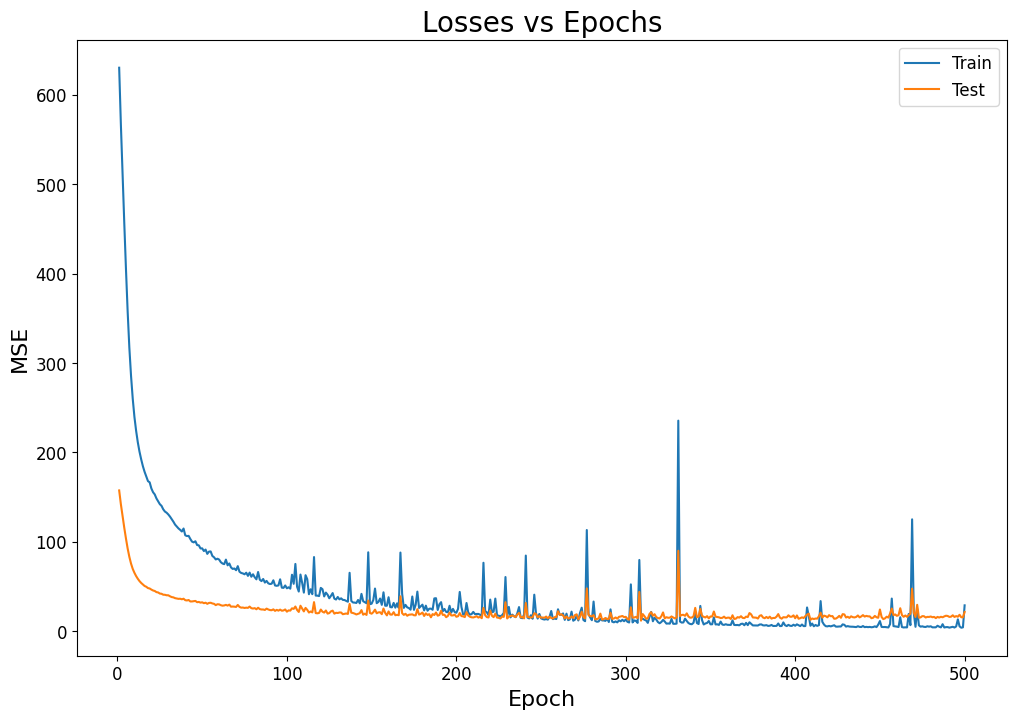

In [165]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(np.arange(1,501),losses_train, label="Train")
ax.plot(np.arange(1,501),losses_test, label="Test")
ax.set(title="Losses vs Epochs", xlabel = "Epoch", ylabel = "MSE")
ax.legend()
plt.show()

In [86]:
logits_test, _ = mlp.predict(X_test_std)   # (N_test, 3)
probs_test = softmax(logits_test)
y_true = np.argmax(y_class_test_onehot, axis=1)

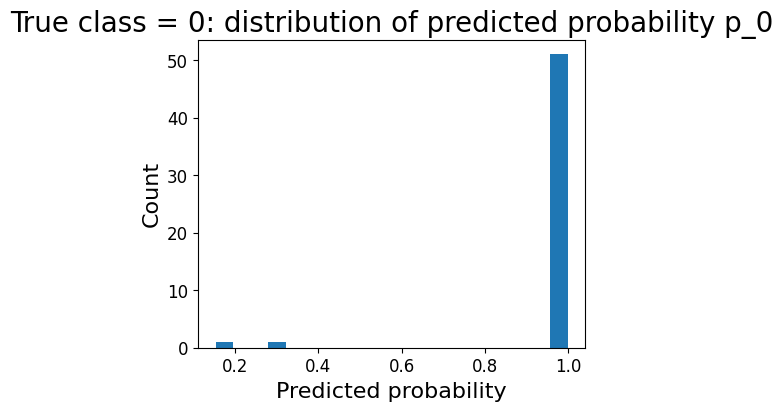

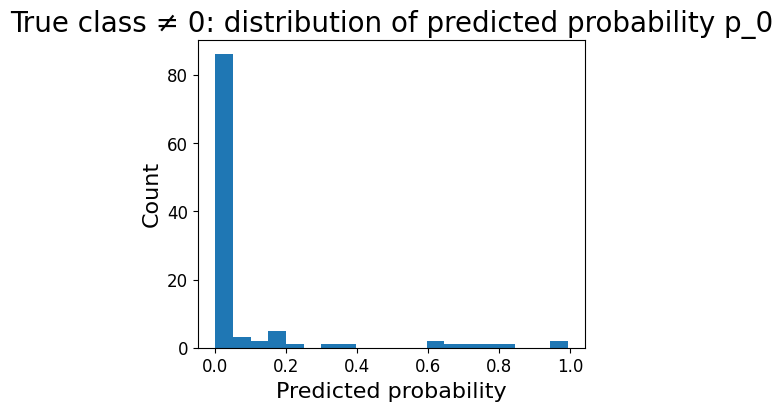

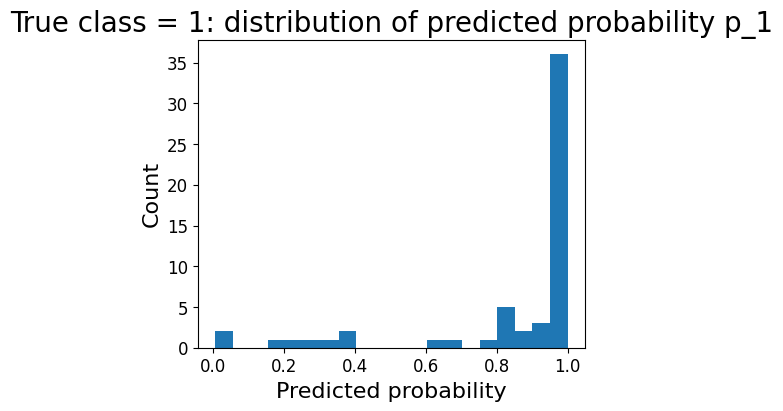

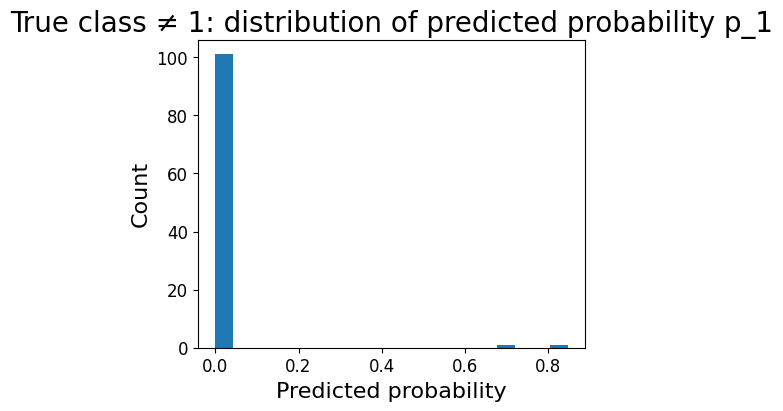

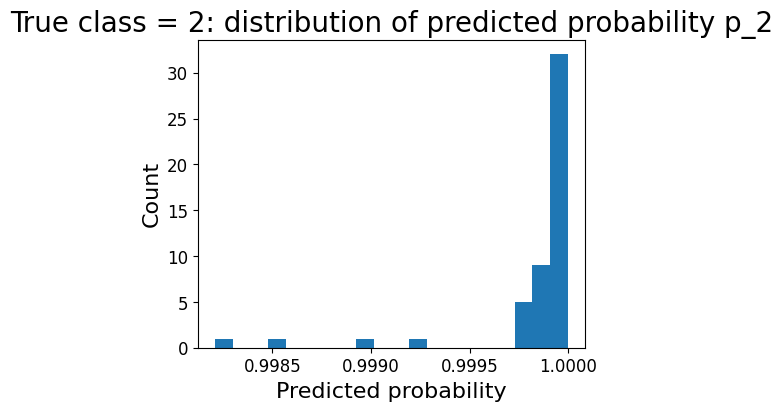

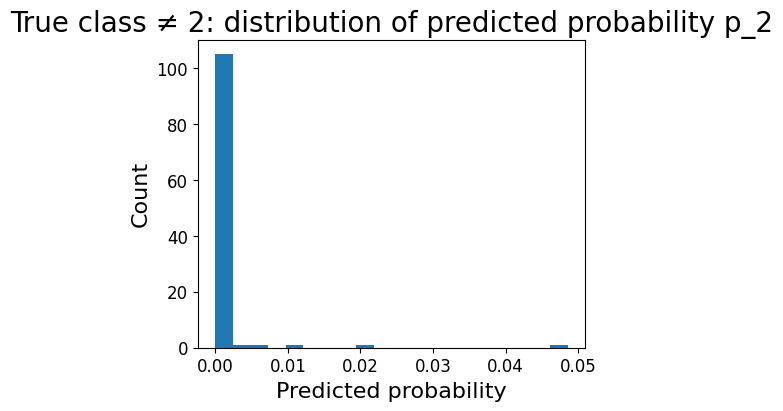

In [87]:
for q in range(3):

    p_q = probs_test[:, q]

    mask_true = (y_true == q)
    mask_false = (y_true != q)

    plt.figure(figsize=(5,4))
    plt.hist(p_q[mask_true], bins=20)
    plt.title(f"True class = {q}: distribution of predicted probability p_{q}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(5,4))
    plt.hist(p_q[mask_false], bins=20)
    plt.title(f"True class ≠ {q}: distribution of predicted probability p_{q}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

<a name="task-32"></a>

## (3.2) [(index)](#index-task-32)

In [88]:
def train_weak_mlp(X, residual, weak_mlp, learning_rate=0.05, n_epochs=1000, minibatchsize=32, seed=42):
    rng = np.random.default_rng(seed)
    n_iterations = int(len(residual) / minibatchsize)
    losses_train = []

    for i in range(n_epochs):
        p = rng.permutation(len(residual))
        X_shuffled = X[p]
        y_shuffled = residual[p]

        for j in range(n_iterations):
            X_batch = X_shuffled[j*minibatchsize : (j+1)*minibatchsize]
            y_batch = y_shuffled[j*minibatchsize : (j+1)*minibatchsize]
            updated_layers = sgd_step(X_batch, y_batch, weak_mlp, learning_rate, "mse")
            weak_mlp.layers = updated_layers

        y_hat_train, _, _ = weak_mlp.predict(X)
        loss_train = mse_loss(residual, y_hat_train).squeeze()
        losses_train.append(loss_train)

        if (i==0) or ((i+1)%200==0):
            print(f'Epoch {i+1}/{n_epochs}: MSE: {loss_train:.6f}')

    return weak_mlp, losses_train

In [89]:
def evaluate_logits(a, y):
    p = softmax(a)
    y_true = np.argmax(y, axis=1)
    y_pred = np.argmax(p, axis=1)

    acc = np.mean(y_true == y_pred)

    per_class = []
    for q in range(y.shape[1]):
        mask = (y_true == q)
        per_class.append(np.mean(y_pred[mask] == q))

    return {"acc": acc, "per_class": per_class}


In [90]:
def gbmlp(X_train, y_train, X_test, y_test, strong_mlp, shrinkage=2, T=4):
    _, a_train, _ = strong_mlp.predict(X_train)
    _, a_test, _ = strong_mlp.predict(X_test)

    history = []

    for t in range(T):
        p_train = softmax(a_train)
        residual_train = y_train - p_train
        weak = MLP(seed=42 + t)
        weak.add_layer(X_train.shape[1], 32, activation="identity")
        weak.add_layer(32, 32, activation="relu")
        weak.add_layer(32, 16, activation="relu")
        weak.add_layer(16, 3, activation="identity")

        weak, _ = train_weak_mlp(X_train, residual_train, weak)

        _, f_train, _ = weak.predict(X_train)
        _, f_test, _  = weak.predict(X_test)
        a_train = a_train + shrinkage * f_train
        a_test  = a_test  + shrinkage * f_test

        metrics = evaluate_logits(a_test, y_test)
        history.append(metrics)
        print(f"iter {t+1}: ", metrics)

    return history, a_train, a_test

In [91]:
history, a_train, a_test = gbmlp(X_train_std, y_class_train_onehot, X_test_std, y_class_test_onehot, mlp)

ValueError: not enough values to unpack (expected 3, got 2)

In [49]:
p_test = softmax(a_test)
accuracy_from_onehot(y_class_test_onehot, p_test)

np.float64(0.96875)